### Phase 1: SQL Data Preparation
Objective:
Simulate an enterprise data environment by ingesting the raw CSV file into a local SQLite database. This allows us to perform initial data extraction, verify data integrity, and pre-aggregate key metrics using standard SQL queries before moving to Python for advanced analysis.

In [17]:
import sqlite3
import pandas as pd

# Establish a connection to a local SQLite database
conn = sqlite3.connect('d2c_ecommerce_project.db')

# Read the raw dataset and load it into the database
raw_df = pd.read_csv("../data/raw/d2c_marketing_funnel_data.csv")
raw_df.to_sql('marketing_funnel', conn, index=False, if_exists='replace')

# Query channel-level performance for downstream analysis
sql_channel = """
SELECT
    channel,
    COUNT(*) AS visitors,
    SUM(CASE WHEN purchase_completed = 'Yes' THEN 1 ELSE 0 END) AS purchases,
    ROUND(SUM(CASE WHEN purchase_completed = 'Yes' THEN 1.0 ELSE 0.0 END) * 100.0 / COUNT(*), 2) AS conversion_rate,
    SUM(revenue) AS total_revenue
FROM marketing_funnel
GROUP BY channel
ORDER BY conversion_rate DESC;
"""
channel_df = pd.read_sql(sql_channel, conn)
channel_df.to_csv('sql_view_channel_performance.csv', index=False)

print(channel_df)
conn.close()

    channel  visitors  purchases  conversion_rate  total_revenue
0     Email     12092        884             7.31    1811300.315
1    Social     18071       1230             6.81    2578443.312
2   Organic     35946       2448             6.81    5090708.447
3  Paid Ads     53891       3619             6.72    7536147.080


### Phase 3: Python Data Cleaning & Feature Engineering

**Objective:** Prepare the dataset for rigorous statistical analysis and visualization. This phase focuses on assessing data quality by checking for missing values and duplicates. Furthermore, it engineers temporal features from date strings and transforms categorical funnel interactions (Yes/No) into a binary numerical format (1/0), which is strictly required for downstream machine learning models and Business Intelligence (BI) integration.

In [18]:
import pandas as pd
import numpy as np

# Load the raw dataset
raw_df = pd.read_csv("../data/raw/d2c_marketing_funnel_data.csv")

# Basic quality checks
print('Missing values:')
print(raw_df.isnull().sum())
print(f'\nDuplicate rows: {raw_df.duplicated().sum()}')

# Convert date and encode binary funnel fields
raw_df['date'] = pd.to_datetime(raw_df['date'])
raw_df['weekday'] = raw_df['date'].dt.day_name()

binary_cols = ['visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed', 'discount_applied']
for col in binary_cols:
    raw_df[col] = raw_df[col].map({'Yes': 1, 'No': 0})

raw_df.to_csv('clean_data_for_analysis.csv', index=False)
print('\nClean data saved.')

Missing values:
user_id               0
session_id            0
date                  0
month                 0
channel               0
campaign_type         0
device                0
user_type             0
region                0
visited_website       0
viewed_product        0
added_to_cart         0
checkout_started      0
purchase_completed    0
discount_applied      0
order_value           0
revenue               0
dtype: int64

Duplicate rows: 0

Clean data saved.


### Phase 4: Exploratory Data Analysis (EDA)

**Objective:** Visually explore the cleaned dataset to identify business trends, user behavior patterns, and critical drop-off points in the marketing funnel. This phase utilizes visualization libraries to answer "What happened?" by mapping out the absolute conversion numbers, analyzing revenue distribution across different acquisition channels, and discovering correlations between various interaction touchpoints.

/var/folders/qj/t6syvx9s0dzbr92pgfqy0x9r0000gn/T/ipykernel_98191/2632347152.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=funnel_counts.values, y=funnel_stages, palette='Blues_r', orient='h')


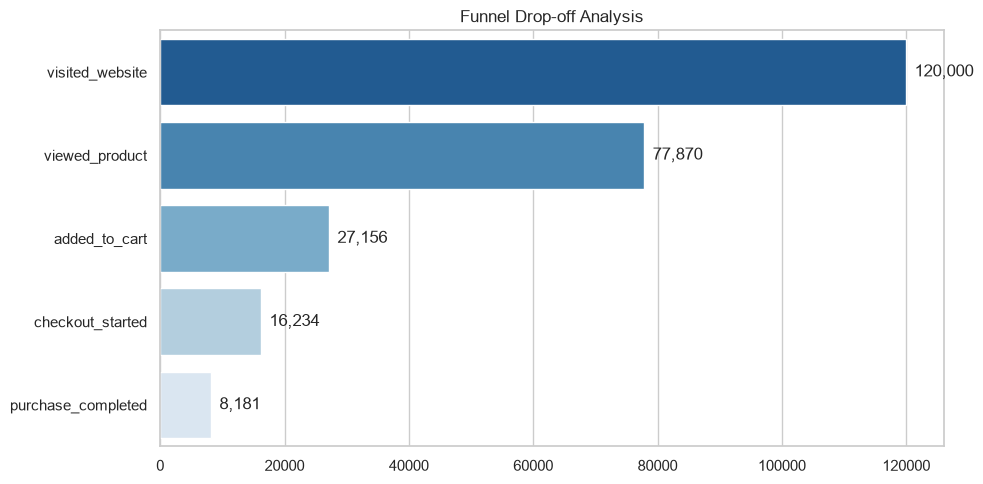

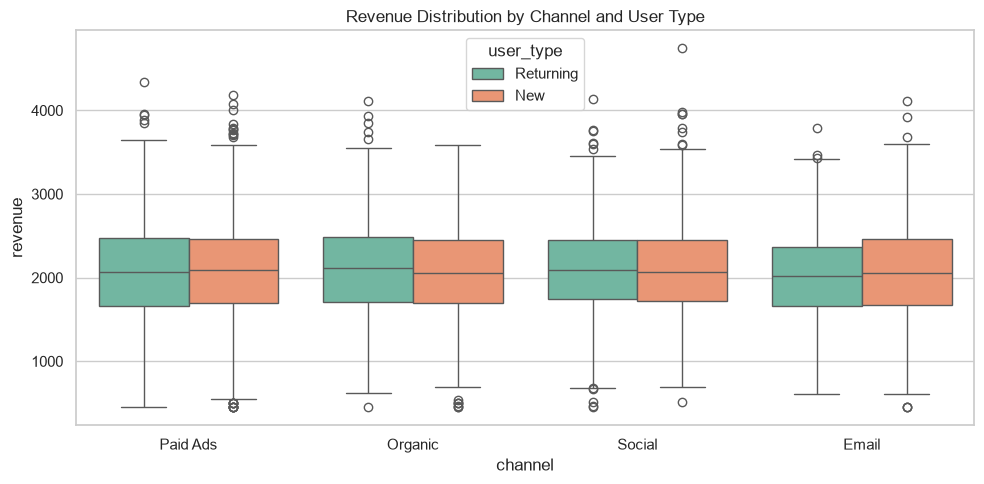

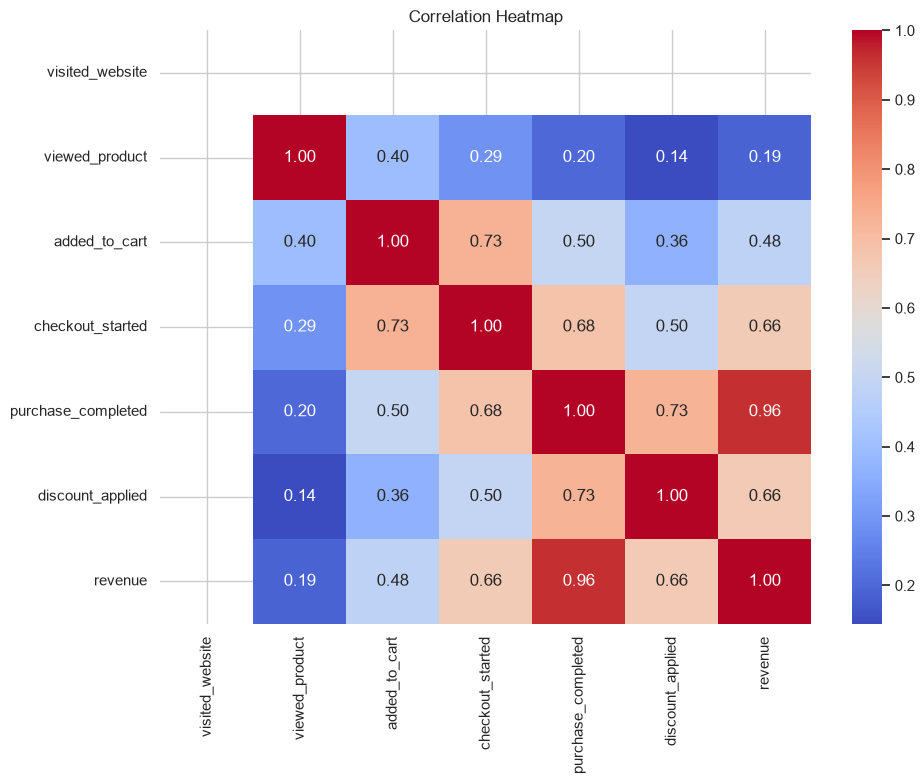

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
df = pd.read_csv("../data/processed/clean_data_for_analysis.csv")

# Funnel drop-off chart
funnel_stages = ['visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed']
funnel_counts = df[funnel_stages].sum()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=funnel_counts.values, y=funnel_stages, palette='Blues_r', orient='h')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2), ha='left', va='center', xytext=(6, 0), textcoords='offset points')
plt.title('Funnel Drop-off Analysis')
plt.tight_layout()
plt.show()

# Revenue distribution by channel
purchasers = df[df['purchase_completed'] == 1]
plt.figure(figsize=(10, 5))
sns.boxplot(data=purchasers, x='channel', y='revenue', hue='user_type', palette='Set2')
plt.title('Revenue Distribution by Channel and User Type')
plt.tight_layout()
plt.show()

# Correlation heatmap
corr_cols = funnel_stages + ['discount_applied', 'revenue']
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Phase 5: Marketing Funnel Analysis

**Objective:** Quantify the exact stage-to-stage conversion and drop-off rates across the customer journey. By calculating the micro-conversion rates between each step and segmenting the funnel by key dimensions (such as Device and Channel), we can isolate specific structural bottlenecks and identify targeted optimization opportunities.

In [20]:
import pandas as pd

# Load cleaned data
df = pd.read_csv("../data/processed/clean_data_for_analysis.csv")
funnel_stages = ['visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed']
stage_counts = df[funnel_stages].sum()

print('Overall funnel conversion rates:')
for i in range(len(funnel_stages)):
    current_stage = funnel_stages[i]
    count = stage_counts[current_stage]
    if i == 0:
        print(f'{current_stage}: {count:,}')
    else:
        prev_stage = funnel_stages[i - 1]
        prev_count = stage_counts[prev_stage]
        conversion_rate = (count / prev_count) * 100
        drop_off_rate = 100 - conversion_rate
        print(f'{prev_stage} -> {current_stage}: {conversion_rate:.2f}% conversion | {drop_off_rate:.2f}% drop-off')

Overall funnel conversion rates:
visited_website: 120,000
visited_website -> viewed_product: 64.89% conversion | 35.11% drop-off
viewed_product -> added_to_cart: 34.87% conversion | 65.13% drop-off
added_to_cart -> checkout_started: 59.78% conversion | 40.22% drop-off
checkout_started -> purchase_completed: 50.39% conversion | 49.61% drop-off


### Phase 6: Statistical & Predictive Analysis

**Objective:** Move beyond descriptive analytics ("what happened") to diagnostic and predictive analytics ("why it happened and what drives it"). This phase applies rigorous statistical hypothesis testing (Chi-Square, T-tests) to validate business assumptions. Furthermore, a Logistic Regression model is trained to calculate the Odds Ratios of various user attributes, quantifying their exact mathematical impact on the likelihood of a completed purchase.

In [21]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import numpy as np

df = pd.read_csv("../data/processed/clean_data_for_analysis.csv")

# Hypothesis test: device vs purchase
contingency = pd.crosstab(df['device'], df['purchase_completed'])
chi2, p_chi2, _, _ = stats.chi2_contingency(contingency)
print(f'Chi-square p-value: {p_chi2:.4f}')

# T-test: discount vs revenue for purchasers
purchasers = df[df['purchase_completed'] == 1]
rev_discount = purchasers[purchasers['discount_applied'] == 1]['revenue']
rev_no_discount = purchasers[purchasers['discount_applied'] == 0]['revenue']
t_stat, p_ttest = stats.ttest_ind(rev_discount, rev_no_discount)
print(f'T-test p-value: {p_ttest:.4e}')

# Logistic regression
X = df[['device', 'user_type', 'channel', 'region']]
X = pd.get_dummies(X, drop_first=True)
X = sm.add_constant(X)
y = df['purchase_completed']
logit_model = sm.Logit(y, X.astype(float)).fit(disp=0)

odds_ratios = np.exp(logit_model.params)
results_df = pd.DataFrame({'Odds Ratio': odds_ratios, 'P-value': logit_model.pvalues})
results_df['Significant?'] = results_df['P-value'] < 0.05
print(results_df.round(4))

Chi-square p-value: 0.4009
T-test p-value: 9.7614e-69
                     Odds Ratio  P-value  Significant?
const                    0.0814   0.0000          True
device_Mobile            0.9785   0.3822         False
user_type_Returning      0.9534   0.0483          True
channel_Organic          0.9265   0.0610         False
channel_Paid Ads         0.9129   0.0193          True
channel_Social           0.9262   0.0937         False
region_Non-Metro         1.0003   0.9891         False
